# Perplexity measures and LLM agent quality
**Warsztaty AI — preliminary results notebook**  
Author: Klaudia Chwistek  
Supervisor: Luiz  
Date: 2026-05  

This notebook reproduces the headline tables and plots from three experiments on **GSM8K** with Qwen2.5 models, in two settings: pure chain-of-thought (CoT) and a single-tool ReAct agent (calculator). The research question is whether **perplexity-family metrics** (perplexity, token-level entropy, top-1 margin, top-1/top-5 mass) carry signal about per-question correctness, and whether *where* in the trajectory one measures them matters.

All cells load precomputed CSVs from `results/` and `overnight_results/`. No model is loaded here — generation code lives in `experiments/run_pilot.py` and `experiments/agent_calculator.py`.

**Run order**: top to bottom. Total wall-time on a laptop: under 5 s.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

REPO = Path.cwd()
while REPO.name and not (REPO / 'experiments').exists():
    REPO = REPO.parent
print('repo root:', REPO)

def fmt_p(p):
    return '<0.001' if p < 0.001 else f'{p:.3f}'


repo root: /home/majowyporanek/magisterka/repos/agent-evaluation-experiments


## 1. Phase 1 — pilot (Qwen-0.5B-Instruct, pure CoT, n=150)

Three seeds × 50 GSM8K examples, greedy decoding. Score continuation with teacher-forced perplexity and mean token entropy of the model's own reasoning.

In [2]:
pilot = pd.concat([
    pd.read_csv(REPO / f'results/results_seed{s}.csv').assign(seed=s)
    for s in (0, 1, 2)
], ignore_index=True)
print(f'n = {len(pilot)}, accuracy = {pilot.correct.mean():.2%}')
pilot.groupby('seed')['correct'].mean()


n = 150, accuracy = 44.67%


seed
0    0.44
1    0.44
2    0.46
Name: correct, dtype: float64

In [3]:
metrics = ['cot_perplexity', 'cot_mean_token_entropy', 'cot_tokens']
rows = []
for m in metrics:
    r, rp = pearsonr(pilot[m], pilot['correct'])
    rho, rhop = spearmanr(pilot[m], pilot['correct'])
    rows.append({'metric': m, 'pearson_r': r, 'pearson_p': rp,
                 'spearman_rho': rho, 'spearman_p': rhop, 'n': len(pilot)})
pd.DataFrame(rows)


,metric,pearson_r,pearson_p,spearman_rho,spearman_p,n
0,cot_perplexity,-0.235743,0.003683,-0.227162,5.181558e-03,150
1,cot_mean_token_entropy,-0.317227,0.000076,-0.329362,3.862984e-05,150
2,cot_tokens,-0.379442,0.000002,-0.416170,1.179380e-07,150


**Reading**: `cot_mean_token_entropy` already outperforms `cot_perplexity` (r ≈ −0.32 vs −0.24). First hint that the entropy/margin family beats geometric mean of chosen-token probabilities. This pattern will replicate in every subsequent experiment.

## 2. Phase 2 — Tool-using ReAct agent (Qwen-1.5B, n=60)

ReAct loop with a single calculator tool, max 5 tool calls per question. Per-segment decoding signals captured directly from `model.generate(output_scores=True)`. Two seeds × 30 questions; the pooled summary CSV concatenates them.

In [4]:
agent = pd.read_csv(REPO / 'overnight_results/agent_15b_n60_pooled_summary.csv')
trace = pd.read_csv(REPO / 'overnight_results/agent_15b_n60_pooled_trace.csv')
print(f'n_questions = {len(agent)}, accuracy = {agent.correct.mean():.2%}, '
      f'truncated = {agent.truncated.mean():.2%}')
agent.groupby('seed')['correct'].mean()


n_questions = 60, accuracy = 28.33%, truncated = 20.00%


seed
0    0.166667
1    0.400000
Name: correct, dtype: float64

In [5]:
# Correlations with `correct` for every numeric agent-level metric.
AGENT_METRICS = [
    'agent_ppl_mean', 'agent_entropy_mean',
    'agent_margin_mean', 'agent_top1_mass_mean',
    'action_ppl_mean', 'action_margin_mean',
    'answer_ppl', 'answer_margin',
]
rows = []
for m in AGENT_METRICS:
    sub = agent[[m, 'correct']].dropna()
    if len(sub) < 5 or sub[m].nunique() < 2:
        continue
    r, rp = pearsonr(sub[m], sub['correct'])
    rho, rhop = spearmanr(sub[m], sub['correct'])
    rows.append({'metric': m, 'n': len(sub),
                 'pearson_r': r, 'pearson_p': rp,
                 'spearman_rho': rho, 'spearman_p': rhop})
pd.DataFrame(rows).sort_values('pearson_r')


,metric,n,pearson_r,pearson_p,spearman_rho,spearman_p
4,action_ppl_mean,48,-0.435644,0.001969,-0.437607,0.001868
1,agent_entropy_mean,60,-0.388073,0.002185,-0.385500,0.002352
0,agent_ppl_mean,60,-0.353893,0.005538,-0.374821,0.003171
6,answer_ppl,48,-0.098857,0.503823,-0.143074,0.331986
7,answer_margin,48,0.105924,0.473660,0.143074,0.331986
3,agent_top1_mass_mean,60,0.379698,0.002770,0.366278,0.003999
2,agent_margin_mean,60,0.380332,0.002721,0.379093,0.002817
5,action_margin_mean,48,0.453982,0.001191,0.420241,0.002941


**Reading**: `action_*` metrics — measured only on tool-call segments — give the strongest signal. `answer_ppl` is essentially noise (p > 0.5). Confidence on the *process* discriminates correctness; confidence on the *conclusion* does not.

In [6]:
# Per-step-type breakdown — does confidence depend on what the model is doing?
step_cols = ['ppl', 'entropy', 'margin', 'top1_mass']
rows = []
for st, grp in trace.groupby('step_type'):
    row = {'step_type': st, 'n': len(grp)}
    for c in step_cols:
        row[f'{c}_mean'] = float(grp[c].mean())
    rows.append(row)
pd.DataFrame(rows).sort_values('ppl_mean')


,step_type,n,ppl_mean,entropy_mean,margin_mean,top1_mass_mean
1,answer,48,1.257937,0.516101,0.794506,0.859913
0,action,107,1.537319,0.990112,0.618539,0.729310
2,thought,41,1.647879,1.050241,0.592140,0.709783


**Reading**: answers are most peaked (lowest PPL, highest margin), thoughts are least. Order is stable across both seeds — not a single-run artefact.

## 3. Phase 3 — Same-model CoT control (Qwen-1.5B, n=60)

Same model and questions as the agent run, but no tool loop. Lets us ask: does putting the model in an agent harness *change* the perplexity-correctness relationship?

In [7]:
cot15 = pd.concat([
    pd.read_csv(REPO / f'overnight_results/cot_15b_n30_seed{s}.csv').assign(seed=s)
    for s in (0, 1)
], ignore_index=True)
print(f'n = {len(cot15)}, accuracy = {cot15.correct.mean():.2%}')
cot15.groupby('seed')['correct'].mean()


n = 60, accuracy = 60.00%


seed
0    0.533333
1    0.666667
Name: correct, dtype: float64

In [8]:
metrics = ['cot_perplexity', 'cot_mean_token_entropy', 'cot_tokens', 'prompt_tokens']
rows = []
for m in metrics:
    r, rp = pearsonr(cot15[m], cot15['correct'])
    rho, rhop = spearmanr(cot15[m], cot15['correct'])
    rows.append({'metric': m, 'pearson_r': r, 'pearson_p': rp,
                 'spearman_rho': rho, 'spearman_p': rhop})
pd.DataFrame(rows)


,metric,pearson_r,pearson_p,spearman_rho,spearman_p
0,cot_perplexity,-0.283101,0.028393,-0.244943,0.059261
1,cot_mean_token_entropy,-0.490081,0.000070,-0.473474,0.000133
2,cot_tokens,-0.316178,0.013852,-0.287853,0.025732
3,prompt_tokens,-0.457814,0.000235,-0.413668,0.001019


**Reading**: `cot_mean_token_entropy` r = −0.49, p < 0.001 — the strongest single perplexity-family signal across the whole project. Putting the model in a ReAct loop drops accuracy from 60 % to 28 % but does not destroy the PPL signal (`action_ppl_mean` still r = −0.44 inside the agent).

## 4. Headline comparison (same model, two settings)


In [9]:
def first_r(df, m):
    sub = df[[m, 'correct']].dropna()
    r, p = pearsonr(sub[m], sub['correct'])
    return r, p, len(sub)

headline = []
for label, df, metric in [
    ('0.5B CoT (pilot)', pilot, 'cot_perplexity'),
    ('0.5B CoT (pilot)', pilot, 'cot_mean_token_entropy'),
    ('1.5B CoT', cot15, 'cot_perplexity'),
    ('1.5B CoT', cot15, 'cot_mean_token_entropy'),
    ('1.5B Agent (full)', agent, 'agent_ppl_mean'),
    ('1.5B Agent (full)', agent, 'agent_entropy_mean'),
    ('1.5B Agent (action)', agent, 'action_ppl_mean'),
    ('1.5B Agent (action)', agent, 'action_margin_mean'),
]:
    r, p, n = first_r(df, metric)
    headline.append({'setting': label, 'metric': metric, 'n': n,
                     'pearson_r': r, 'pearson_p': p})
pd.DataFrame(headline)


,setting,metric,n,pearson_r,pearson_p
0,0.5B CoT (pilot),cot_perplexity,150,-0.235743,0.003683
1,0.5B CoT (pilot),cot_mean_token_entropy,150,-0.317227,0.000076
2,1.5B CoT,cot_perplexity,60,-0.283101,0.028393
3,1.5B CoT,cot_mean_token_entropy,60,-0.490081,0.000070
4,1.5B Agent (full),agent_ppl_mean,60,-0.353893,0.005538
5,1.5B Agent (full),agent_entropy_mean,60,-0.388073,0.002185
6,1.5B Agent (action),action_ppl_mean,48,-0.435644,0.001969
7,1.5B Agent (action),action_margin_mean,48,0.453982,0.001191


Two consistent patterns visible across every row of this table:

1. **Entropy / margin > PPL** in every setting and at both model sizes.
2. **Where you measure inside an agent matters** — action-segment metrics carry the strongest signal we see anywhere on 1.5B.

## 5. Bootstrap 95 % CI for the agent headline

Same procedure as `experiments/agent_bootstrap.py` — resample questions with replacement 5000 times and report the 2.5 / 97.5 percentiles of the Pearson r distribution.

In [10]:
def bootstrap_pearson(x, y, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    rs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb, yb = x[idx], y[idx]
        rs[b] = np.corrcoef(xb, yb)[0, 1] if xb.std() and yb.std() else np.nan
    return rs

rows = []
for m in ['action_ppl_mean', 'action_margin_mean', 'agent_ppl_mean',
          'agent_margin_mean', 'agent_entropy_mean', 'answer_ppl']:
    sub = agent[[m, 'correct']].dropna()
    if len(sub) < 5:
        continue
    x, y = sub[m].values.astype(float), sub['correct'].values.astype(float)
    r, p = pearsonr(x, y)
    rs = bootstrap_pearson(x, y)
    rs = rs[~np.isnan(rs)]
    rows.append({'metric': m, 'n': len(sub), 'pearson_r': r, 'pearson_p': p,
                 'ci_lo': np.quantile(rs, 0.025),
                 'ci_hi': np.quantile(rs, 0.975)})
pd.DataFrame(rows).sort_values('pearson_r')


,metric,n,pearson_r,pearson_p,ci_lo,ci_hi
0,action_ppl_mean,48,-0.435644,0.001969,-0.602807,-0.237526
4,agent_entropy_mean,60,-0.388073,0.002185,-0.537221,-0.229339
2,agent_ppl_mean,60,-0.353893,0.005538,-0.488473,-0.219448
5,answer_ppl,48,-0.098857,0.503823,-0.311983,0.204623
3,agent_margin_mean,60,0.380332,0.002721,0.200600,0.545607
1,action_margin_mean,48,0.453982,0.001191,0.206649,0.647582


## 6. Calibration — reliability diagrams + ECE

Confidence = 1 / perplexity (under greedy decoding this is the geometric mean of top-1 probabilities, a value in (0, 1]). Equal-frequency binning. ECE = sum_b (n_b / N) · |mean(conf in bin) − mean(correct in bin)|.

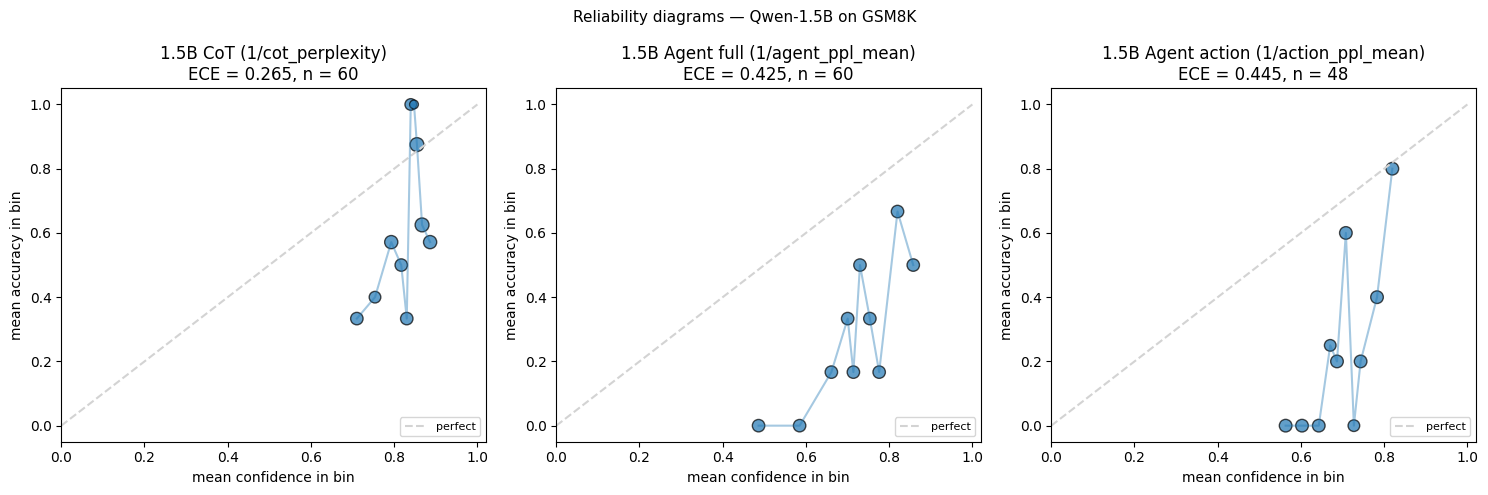

In [11]:
def reliability(conf, correct, n_bins=10):
    if len(conf) < n_bins:
        n_bins = max(2, len(conf) // 2)
    edges = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
    edges[0] -= 1e-9
    bins = np.digitize(conf, edges[1:-1])
    rows = []
    ece = 0.0
    for b in range(bins.max() + 1):
        m = bins == b
        if not m.any():
            continue
        c_mean, a_mean = conf[m].mean(), correct[m].mean()
        ece += (m.sum() / len(conf)) * abs(c_mean - a_mean)
        rows.append({'n': int(m.sum()), 'conf': c_mean, 'acc': a_mean})
    return ece, pd.DataFrame(rows)

settings = [
    ('1.5B CoT (1/cot_perplexity)', 1 / cot15['cot_perplexity'].values, cot15['correct'].values),
    ('1.5B Agent full (1/agent_ppl_mean)', 1 / agent['agent_ppl_mean'].values, agent['correct'].values),
]
act = agent[agent['action_ppl_mean'].notna()]
settings.append(('1.5B Agent action (1/action_ppl_mean)',
                 1 / act['action_ppl_mean'].values, act['correct'].values))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, conf, corr) in zip(axes, settings):
    ece_val, tab = reliability(conf, corr)
    ax.plot([0, 1], [0, 1], '--', color='lightgray', label='perfect')
    sizes = (tab['n'] / tab['n'].sum()) * 600 + 20
    ax.scatter(tab['conf'], tab['acc'], s=sizes, alpha=0.7, edgecolor='black')
    ax.plot(tab['conf'], tab['acc'], alpha=0.4)
    ax.set_xlim(0, 1.02); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('mean confidence in bin'); ax.set_ylabel('mean accuracy in bin')
    ax.set_title(f'{label}\nECE = {ece_val:.3f}, n = {len(conf)}')
    ax.legend(loc='lower right', fontsize=8)
fig.suptitle('Reliability diagrams — Qwen-1.5B on GSM8K', fontsize=11)
fig.tight_layout()
plt.show()


**Reading**: All three settings are visibly mis-calibrated (ECE > 0.2 is considered poor). The 1.5B CoT model is the **best** calibrated (ECE ≈ 0.27); putting the same model in an agent loop makes it markedly more over-confident (ECE ≈ 0.43–0.45). Note the dissociation from the correlation results: action-segment PPL is the *most discriminative* signal we have, but the agent is the *least calibrated* setting. Correlation and calibration are different questions.

## 7. Findings

1. **Entropy / margin beat PPL** as predictors of correctness in every setting tested (0.5B-CoT, 1.5B-CoT, 1.5B-Agent). PPL has historical priority as a calibration signal but is not the best-performing member of its own family.

2. **Strongest single signal**: `cot_mean_token_entropy` on 1.5B-CoT, r = −0.49, p < 0.001 (n = 60).

3. **Putting Qwen-1.5B in a ReAct + calculator loop drops accuracy from 60 % to 28 %** on the same questions. The agent harness imposes overhead that this model size cannot reliably bear (frequent format errors, ~25 % truncation).

4. **Inside the agent, where you measure PPL matters**: action segments carry the strongest signal (r = −0.44, 95 % CI [−0.60, −0.25]); the final-answer segment alone carries essentially none (r = −0.10, CI straddles zero). Confidence discriminates on the *process*, not the *conclusion*.

5. **Confidence depends systematically on ReAct step type**: answers most peaked, thoughts least. Replicates across both seeds.

6. **The agent is more over-confident than the same model in pure CoT** (ECE 0.43 vs 0.27). The PPL signal becomes *more* discriminative inside an agent but the model also becomes *less* calibrated. These are dissociable.

## Limitations

- Small models (0.5B, 1.5B). Calibration is known to improve with scale.
- One dataset (GSM8K), one domain (grade-school maths).
- Greedy decoding compresses PPL near 1.0. Repeating with sampling and self-consistency would let `1 / PPL` move further from the ceiling.
- Same-model scoring throughout — PPL on the model's own generation is biased low. A cross-model evaluator (e.g. score 0.5B outputs with 7B) would be cleaner but was out of scope.
- n = 60 for the headline experiments. Sufficient for p < 0.01 on the main correlations but too small for sub-group analyses.
